# Walk-forward learning on SP100 daily prices (`Mains.multislice`)

This notebook walks through the **multislice** pipeline.
> **Note:** The bundled dataset is `datasets/sp100_daily_prices.csv` (S&P 100 constituents)

In [ ]:
#Imports and static variables
import os
import importlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap

import Utils
import FeatureGeneration as FG
import RBFBinner
import Mains
import Display


for m in (Utils, FG, Mains, Display):
    importlib.reload(m)
WORKDIR = os.path.dirname(os.path.abspath("Mains.py")) if os.path.exists("Mains.py") else os.getcwd()
os.chdir(WORKDIR)
FIGDIR = "figs/SP100/multislice_demo"
os.makedirs(FIGDIR, exist_ok=True)


def figpath(n, stem):
    """Numbered figure path under FIGDIR (``01_…`` through ``99_…``)."""
    return os.path.join(FIGDIR, f"{int(n):02d}_{stem}.png")


def save_fig(fig, n, stem):
    """Save *fig* to FIGDIR with a zero-padded sequence number."""
    path = figpath(n, stem)
    fig.savefig(path, dpi=150, bbox_inches="tight")
    return path

# Figure index (all saved under FIGDIR via save_fig / figpath):
#  01 raw_sp100_closes
#  02 rolling_features_<sym>  
#  03 rbf_encoding_<sym>
#  04 block_coverage_train_val_test
#  05 per_ticker_test_rmse_by_block   
#  06 best_worst_performer_prices
#  07 aggregate_test_error_vs_block   
#  08 test_rmse_heatmap_tickers_blocks
#  09 cross_sectional_mean_test_rmse
#  10 block_sweep_test_rmse_vs_n_blocks   
#  11 block_sweep_rmse_phases   12 block_sweep_elapsed_time
#  13 multislice_prediction_<sym>
#  14 ticker_sweep_test_rmse_vs_n_tickers   
#  15 ticker_sweep_rmse_phases   
#  16 ticker_sweep_elapsed_time
#  17 deriv_transition_<sym>   
#  18 deriv_persistence_<sym>
#  19 deriv_transition_all  
#  20 deriv_persistence_all  
#  21 deriv_persistence_summary



PARAMFILE = "Parameters_multislice.par"
params = Utils.load_params(PARAMFILE)
if "tickers" in params:
    TICKERS = params["tickers"].split(",")
else:
    TICKERS = FG.csv_ticker_columns(params["timeseries_file"])
TRNPAT = int(params["trnpat"])
VANPAT = int(params["vanpat"])
TENPAT = int(params["tenpat"])
OFFS = int(params["offs"])
WARMUP_PAT = int(params.get("warmup_pat", 0))
MEAN_NBIN = int(params["mean_nbin"])
DERIV1ST_NBIN = int(params["deriv1st_nbin"])
BLOCK_STEP = TRNPAT + VANPAT + TENPAT
W = FG.ROLLING_WINDOW_N

if WARMUP_PAT > 0:
    for name, per_t_len in (("trnpat", TRNPAT), ("vanpat", VANPAT), ("tenpat", TENPAT)):
        if per_t_len <= WARMUP_PAT + OFFS:
            raise ValueError(
                f"{name}={per_t_len} must be > warmup_pat + offs "
                f"({WARMUP_PAT + OFFS}) when warmup is enabled.")

print(f"Working directory: {WORKDIR}")
print(f"Tickers ({len(TICKERS)}): {TICKERS}")
print(f"Per-ticker per-block: trnpat={TRNPAT}  vanpat={VANPAT}  tenpat={TENPAT}  "
      f"warmup_pat={WARMUP_PAT}  block_step={BLOCK_STEP}")
if WARMUP_PAT > 0:
    scored_k1 = TRNPAT - WARMUP_PAT - OFFS
    print(f"  scored steps per segment (k>0): train/val/test = "
          f"{scored_k1}/{VANPAT - WARMUP_PAT - OFFS}/{TENPAT - WARMUP_PAT - OFFS}")


Working directory: /home/fiebig/Dropbox/GIT/BCPNNSim2.2_UC2/tests/UC2-EXTRABRAIN/LTSLtest/financial
Tickers (98): ['AAPL', 'ABT', 'ADBE', 'AIG', 'ALL', 'AMGN', 'AMT', 'AMZN', 'AXP', 'BA', 'BAC', 'BK', 'BKNG', 'BLK', 'BMY', 'C', 'CAT', 'CL', 'CMCSA', 'COF', 'COP', 'COST', 'CSCO', 'CVS', 'CVX', 'DD', 'DHR', 'DIS', 'DUK', 'EMR', 'EXC', 'F', 'FDX', 'GD', 'GE', 'GILD', 'GS', 'HD', 'HON', 'IBM', 'INTC', 'JNJ', 'JPM', 'KO', 'LIN', 'LLY', 'LMT', 'LOW', 'MCD', 'MDT', 'MMM', 'MO', 'MRK', 'MS', 'MSFT', 'NEE', 'NKE', 'NVDA', 'ORCL', 'PEP', 'PFE', 'PG', 'QCOM', 'RTX', 'SBUX', 'SLB', 'SO', 'SPG', 'T', 'TGT', 'TMO', 'TXN', 'UNH', 'UNP', 'UPS', 'USB', 'VZ', 'WBA', 'WFC', 'WMT', 'XOM', 'MET', 'MDLZ', 'ACN', 'NFLX', 'CRM', 'GOOGL', 'MA', 'PM', 'V', 'AVGO', 'CHTR', 'GM', 'META', 'ABBV', 'KHC', 'PYPL', 'DOW']
Per-ticker per-block: trnpat=750  vanpat=52  tenpat=200  warmup_pat=50  block_step=1002
  scored steps per segment (k>0): train/val/test = 699/1/149


## 1. Raw SP100 close prices

The wide CSV has one row per trading day and one column per ticker. Values are **adjusted close prices**
(already split-adjusted in the source file). Late-IPO names (e.g. META, GOOGL) have leading `NaN`s until their
first quote; `Mains.multislice()` only activates a ticker in blocks where its feature history fully covers
the block window.

In [55]:
csv_path = FG.dataset_path("sp100_daily_prices.csv")
df_raw = pd.read_csv(csv_path, parse_dates=["Date"])
print(f"Calendar rows: {len(df_raw)}  |  columns (excl. Date): {len(df_raw.columns) - 1}")
print(f"Date range: {df_raw['Date'].iloc[0].date()} → {df_raw['Date'].iloc[-1].date()}")
display(df_raw[TICKERS].describe().T[["count", "min", "max"]].head(10))

Calendar rows: 6324  |  columns (excl. Date): 98
Date range: 2000-01-03 → 2025-02-24


,count,min,max
AAPL,6324.0,0.197414,258.735504
ABT,6324.0,7.013040,134.949997
ADBE,6324.0,8.317788,688.369995
AIG,6324.0,4.493934,1250.231201
ALL,6324.0,9.701691,207.389999
AMGN,6324.0,21.674702,332.021027
AMT,6324.0,0.537356,274.084869
AMZN,6324.0,0.298500,242.059998
AXP,6324.0,8.018998,325.869995
BA,6324.0,16.991482,430.299988


'figs/SP100/multislice_demo/01_raw_sp100_closes.png'

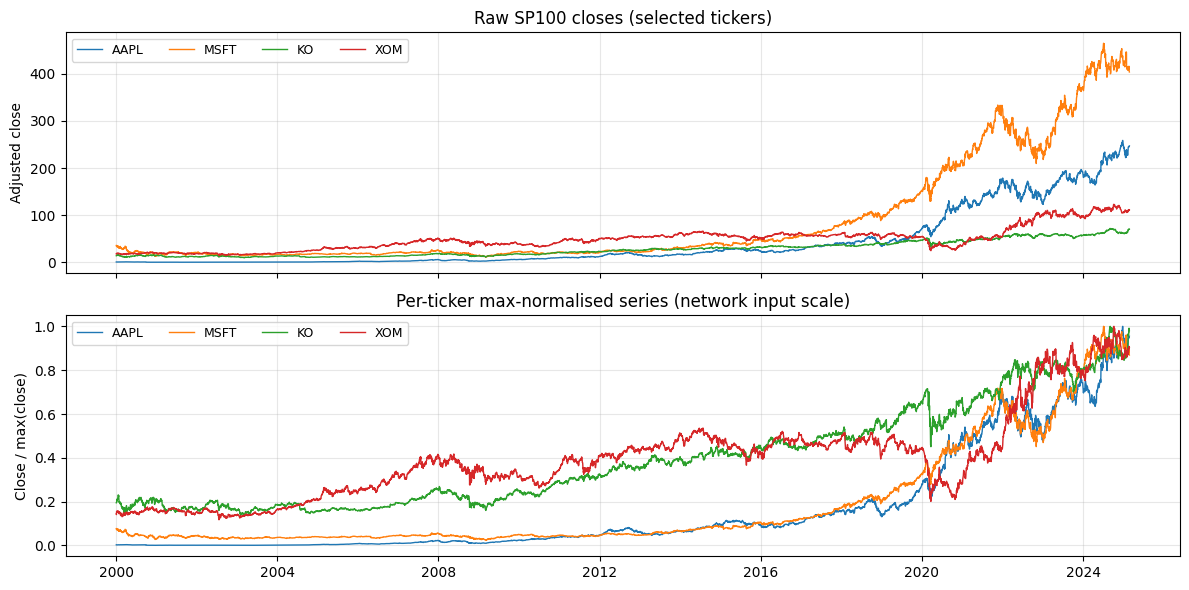

In [56]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
sample = ["AAPL", "MSFT", "KO", "XOM"]
for sym in sample:
    axes[0].plot(df_raw["Date"], df_raw[sym], label=sym, lw=1)
axes[0].set_ylabel("Adjusted close")
axes[0].set_title("Raw SP100 closes (selected tickers)")
axes[0].legend(ncol=4, fontsize=9)
axes[0].grid(alpha=0.3)

# Normalised view (per-ticker max scaling — same as FeatureGeneration.load_tickers_features)
for sym in sample:
    s = df_raw[sym].dropna()
    axes[1].plot(s.index.map(lambda i: df_raw.loc[i, "Date"]), s / s.max(), label=sym, lw=1)
axes[1].set_ylabel("Close / max(close)")
axes[1].set_title("Per-ticker max-normalised series (network input scale)")
axes[1].legend(ncol=4, fontsize=9)
axes[1].grid(alpha=0.3)
plt.tight_layout()
save_fig(fig, 1, "raw_sp100_closes")


## 2. Rolling features and RBF encoding

`FeatureGeneration.make_mean_derivative_features` builds four columns per time step
(after a rolling window of `ROLLING_WINDOW_N = 7` days):

| col | meaning |
|-----|---------|
| 0 | normalised close (value) |
| 1 | 1st derivative (finite difference) |
| 2 | 2nd derivative |
| 3 | trailing mean of value |

The LTSL network predicts column **3** (mean) at horizon `offs` days ahead.
Inputs are encoded by **two independent 1-D RBF binnings** (mean and 1st derivative), then combined
via an outer product → `mean_nbin × deriv1st_nbin` binary-ish pattern rows written to `features.dat`.

'figs/SP100/multislice_demo/02_rolling_features_AAPL.png'

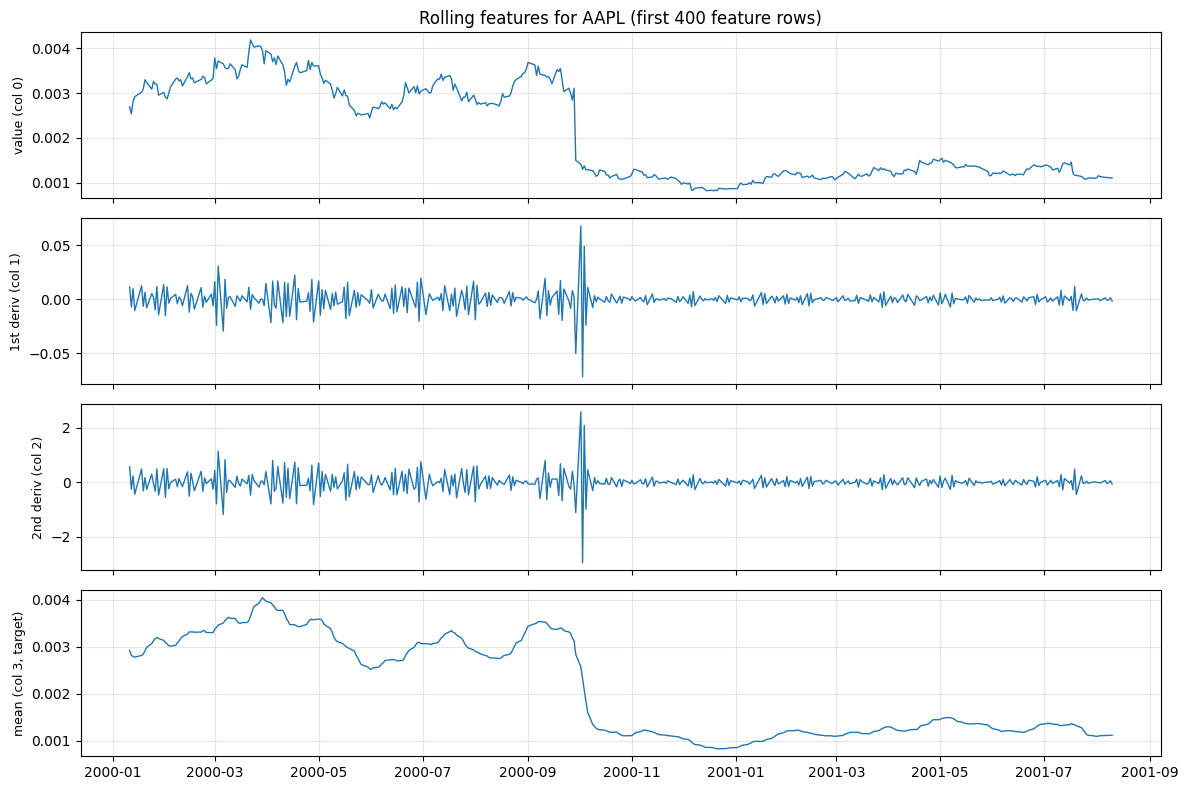

In [57]:
per_ticker, csv_lens = FG.load_tickers_features("sp100_daily_prices.csv", ",".join(TICKERS))
demo_sym = "AAPL"
feats = per_ticker[demo_sym]["feats"]
n_show = 400
t_axis = df_raw["Date"].iloc[per_ticker[demo_sym]["first_valid_feat_row"]:][:n_show]

fig, axs = plt.subplots(4, 1, figsize=(12, 8), sharex=True)
labels = ["value (col 0)", "1st deriv (col 1)", "2nd deriv (col 2)", "mean (col 3, target)"]
for k, ax in enumerate(axs):
    ax.plot(t_axis, feats[:n_show, k], lw=1)
    ax.set_ylabel(labels[k], fontsize=9)
    ax.grid(alpha=0.3)
axs[0].set_title(f"Rolling features for {demo_sym} (first {n_show} feature rows)")
plt.tight_layout()
save_fig(fig, 2, f"rolling_features_{demo_sym}")


Mean decode max |error|: 0.001592


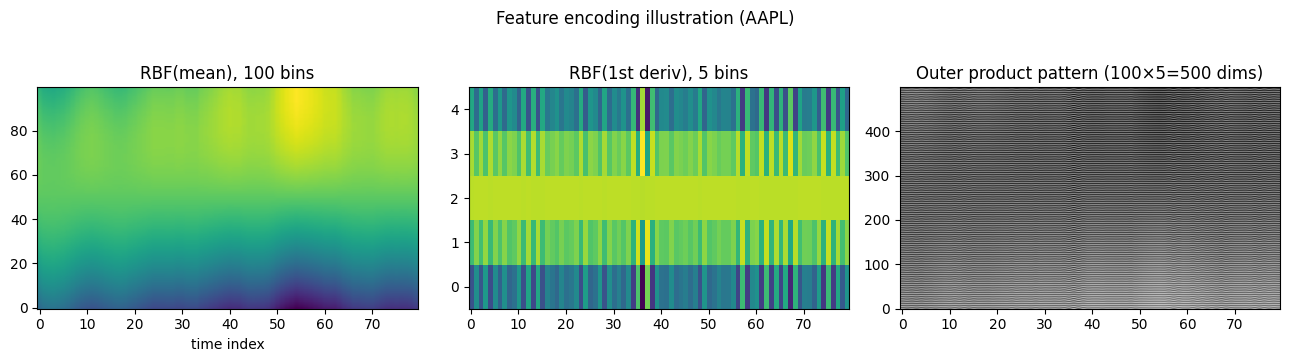

In [58]:
# RBF encoding on a short slice (global min/max would be used in multislice over all blocks)
slice_feats = feats[:500]
enc_mean = RBFBinner.Encoder1D(slice_feats[:, 3].min(), slice_feats[:, 3].max(),
                               MEAN_NBIN, 1.0 / MEAN_NBIN)
enc_d1 = RBFBinner.Encoder1D(slice_feats[:, 1].min(), slice_feats[:, 1].max(),
                             DERIV1ST_NBIN, 1.0 / DERIV1ST_NBIN)
p_mean = enc_mean.encode(slice_feats[:, 3])
p_d1 = enc_d1.encode(slice_feats[:, 1])
patterns = (p_mean[:, :, None] * p_d1[:, None, :]).reshape(len(slice_feats), -1)

fig, axs = plt.subplots(1, 3, figsize=(13, 3.5))
axs[0].imshow(p_mean[:80].T, aspect="auto", origin="lower", cmap="viridis")
axs[0].set_title(f"RBF(mean), {MEAN_NBIN} bins")
axs[0].set_xlabel("time index")
axs[1].imshow(p_d1[:80].T, aspect="auto", origin="lower", cmap="viridis")
axs[1].set_title(f"RBF(1st deriv), {DERIV1ST_NBIN} bins")
axs[2].imshow(patterns[:80].T, aspect="auto", origin="lower", cmap="Greys")
axs[2].set_title(f"Outer product pattern ({MEAN_NBIN}×{DERIV1ST_NBIN}={patterns.shape[1]} dims)")
plt.suptitle(f"Feature encoding illustration ({demo_sym})", y=1.02)
plt.tight_layout()
save_fig(fig, 3, f"rbf_encoding_{demo_sym}")

# Decode round-trip on mean channel
recon = enc_mean.decode(p_mean)
print(f"Mean decode max |error|: {np.max(np.abs(recon - slice_feats[:, 3])):.4g}")


## 3. Block-wise walk-forward schedule

Instead of holding out entire tickers for testing (which leaks calendar structure), **multislice** cuts
the shared timeline into consecutive blocks. Block `b` spans feature rows
`[calendar_start + b·block_step, …)` with `calendar_start = W−1`.

Within each block, patterns are concatenated in order:

`[train_t0, train_t1, …, val_t0, …, test_t0, …]`

The C++ simulator reads one row per block from `schedule.dat` (`trnpat vanpat tenpat` **totals** for that
block, summed over active tickers). Network state (weights + LTSL memory) **carries across blocks** — this
is continual learning on a single long run.

**Warmup (`warmup_pat`, default 50):** at each ticker-to-ticker cut within a phase (`k > 0`), the first
`warmup_pat` patterns are replayed forward-only (LTSL adapts, weights frozen, outputs not logged). RMSE is
computed only on the remaining suffix of each segment. The first ticker in each phase (`k = 0`) is scored
over the full window. Warmup does **not** add calendar rows or change `block_step`; it replays within each
ticker's `trnpat` / `vanpat` / `tenpat` budget. Require each phase length to be **> `warmup_pat + offs`**; set
`warmup_pat 0` to disable.

Candidate blocks (longest history): 6


'figs/SP100/multislice_demo/04_block_coverage_train_val_test.png'

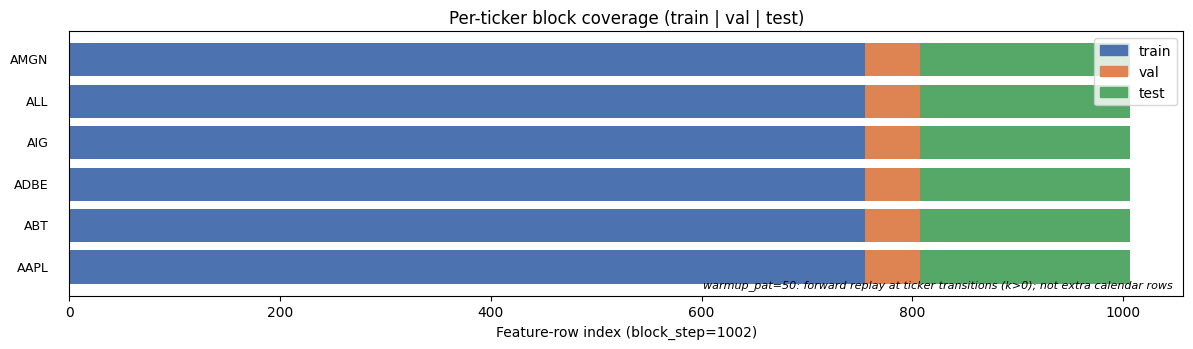

In [59]:
calendar_start = W - 1
max_end = max(d["first_valid_feat_row"] + d["feats"].shape[0] for d in per_ticker.values())
n_blocks = (max_end - calendar_start) // BLOCK_STEP
print(f"Candidate blocks (longest history): {n_blocks}")

# Calendar coverage: train | val | test per block (warmup replays within per_t_len — no extra rows)
phase_colors = {"train": "#4C72B0", "val": "#DD8452", "test": "#55A868"}
fig, ax = plt.subplots(figsize=(12, 0.35 * len(TICKERS[:6]) + 1.5))

for row, sym in enumerate(TICKERS[:6]):
    d = per_ticker[sym]
    fv = d["first_valid_feat_row"]
    n_feat = d["feats"].shape[0]
    for b in range(n_blocks):
        b_start = calendar_start + b * BLOCK_STEP
        sl = b_start - fv
        if sl < 0 or sl + BLOCK_STEP > n_feat:
            continue
        x0 = b
        phase_x = x0
        ax.barh(row, TRNPAT, left=phase_x, color=phase_colors["train"], height=0.8)
        phase_x += TRNPAT
        ax.barh(row, VANPAT, left=phase_x, color=phase_colors["val"], height=0.8)
        phase_x += VANPAT
        ax.barh(row, TENPAT, left=phase_x, color=phase_colors["test"], height=0.8)
    ax.text(-0.02 * BLOCK_STEP, row, sym, ha="right", va="center", fontsize=9)

ax.set_xlabel(f"Feature-row index (block_step={BLOCK_STEP})")
ax.set_yticks([])
ax.set_title("Per-ticker block coverage (train | val | test)")
legend_handles = [Patch(color=c, label=k) for k, c in phase_colors.items()]
ax.legend(handles=legend_handles, loc="upper right")
if WARMUP_PAT > 0:
    ax.text(
        0.99, 0.02,
        f"warmup_pat={WARMUP_PAT}: forward replay at ticker transitions (k>0); not extra calendar rows",
        transform=ax.transAxes, ha="right", va="bottom", fontsize=8, style="italic")
plt.tight_layout()
save_fig(fig, 4, "block_coverage_train_val_test")


In [60]:
# Map block indices to calendar dates (using AAPL as reference timeline)
ref = per_ticker["AAPL"]
ref_dates = df_raw["Date"].iloc[ref["first_valid_feat_row"]: ref["first_valid_feat_row"] + ref["feats"].shape[0]]

block_table = []
for b in range(n_blocks):
    sl = calendar_start + b * BLOCK_STEP - ref["first_valid_feat_row"]
    active = [sym for sym in TICKERS
              if 0 <= (calendar_start + b * BLOCK_STEP - per_ticker[sym]["first_valid_feat_row"])
              and (calendar_start + b * BLOCK_STEP - per_ticker[sym]["first_valid_feat_row"] + BLOCK_STEP)
              <= per_ticker[sym]["feats"].shape[0]]
    block_table.append({
        "block": b,
        "train_start": ref_dates.iloc[sl].date() if 0 <= sl < len(ref_dates) else None,
        "test_end": ref_dates.iloc[min(sl + BLOCK_STEP - 1, len(ref_dates)-1)].date() if sl >= 0 else None,
        "n_active_tickers": len(active),
        "schedule_trn": len(active) * TRNPAT,
        "schedule_ten": len(active) * TENPAT,
    })
pd.DataFrame(block_table)

,block,train_start,test_end,n_active_tickers,schedule_trn,schedule_ten
0,0,2000-01-11,2004-01-07,81,60750,16200
1,1,2004-01-08,2007-12-31,85,63750,17000
2,2,2008-01-02,2011-12-20,88,66000,17600
3,3,2011-12-21,2015-12-15,93,69750,18600
4,4,2015-12-16,2019-12-09,97,72750,19400
5,5,2019-12-10,2023-12-01,98,73500,19600


## 4. Run Mains.multislice() on the complete ticker list
This invokes ./ltslmain once with the full multi-block schedule. 

In [61]:
#Comment out to skip re-running ltslmain (takes ~21 minutes)
result = Mains.multislice(PARAMFILE, exefile="./ltslmain", verbose=True)

Mains.multislice: timeseries_file=sp100_IPO_sorted.csv
  tickers=['AAPL', 'ABT', 'ADBE', 'AIG', 'ALL', 'AMGN', 'AMT', 'AMZN', 'AXP', 'BA', 'BAC', 'BK', 'BKNG', 'BLK', 'BMY', 'C', 'CAT', 'CL', 'CMCSA', 'COF', 'COP', 'COST', 'CSCO', 'CVS', 'CVX', 'DD', 'DHR', 'DIS', 'DUK', 'EMR', 'EXC', 'F', 'FDX', 'GD', 'GE', 'GILD', 'GS', 'HD', 'HON', 'IBM', 'INTC', 'JNJ', 'JPM', 'KO', 'LIN', 'LLY', 'LMT', 'LOW', 'MCD', 'MDT', 'MMM', 'MO', 'MRK', 'MS', 'MSFT', 'NEE', 'NKE', 'NVDA', 'ORCL', 'PEP', 'PFE', 'PG', 'QCOM', 'RTX', 'SBUX', 'SLB', 'SO', 'SPG', 'T', 'TGT', 'TMO', 'TXN', 'UNH', 'UNP', 'UPS', 'USB', 'VZ', 'WBA', 'WFC', 'WMT', 'XOM', 'MET', 'MDLZ', 'ACN', 'NFLX', 'CRM', 'GOOGL', 'MA', 'PM', 'V', 'AVGO', 'CHTR', 'GM', 'META', 'ABBV', 'KHC', 'PYPL', 'DOW']
  trnpat=750  vanpat=52  tenpat=200  warmup_pat=50  block_step=1002
  calendar_start=6  max_calendar_end=6324  candidate blocks=6
  n_blocks=6  total feature rows=543084  (per-phase totals: trn=406500, van=28184, ten=108400)


Hj = 1 nactHi = 5 nsilHi = 0 denHi = 5 Mi = 500 denNi = 2500


paramfile = Parameters_multislice.par
schedule_file = schedule.dat  (6 blocks; sum trn=406500 van=28184 ten=108400)
warmup_pat = 50  (forward-only at ticker transitions k>0)
taup = 406.500
eps = 2.5e-06
K_mode = logarithmic
BLOCK 1/6  trnpat=60750 vanpat=4212 tenpat=16200  (simstep=0)
BLOCK 2/6  trnpat=63750 vanpat=4420 tenpat=17000  (simstep=141588)
BLOCK 3/6  trnpat=66000 vanpat=4576 tenpat=17600  (simstep=290168)
BLOCK 4/6  trnpat=69750 vanpat=4836 tenpat=18600  (simstep=443992)
BLOCK 5/6  trnpat=72750 vanpat=5044 tenpat=19400  (simstep=606556)
BLOCK 6/6  trnpat=73500 vanpat=5096 tenpat=19600  (simstep=776112)
Total simsteps = 947416, time elapsed = 800.040 sec
  train: mean RMSE = 0.01446  persistence = 0.0017967  (542/588 valid entries)
  val  : mean RMSE = 0.024452  persistence = 0.0011519  (542/588 valid entries)
  test : mean RMSE = 0.014461  persistence = 0.0017806  (542/588 valid entries)


In [62]:
rmse = result["rmse"]          # [n_tickers, 3 phases, n_blocks]
valid = result["valid"]
pers = result["persistence"]
labels = result["tickers"]
n_blocks_run = result["n_blocks"]
phase_names = ["train", "val", "test"]

print(f"RMSE cube shape: {rmse.shape}  (tickers × phases × blocks)")
print(f"Blocks executed: {n_blocks_run}")
print(f"warmup_pat: {result.get('warmup_pat', 0)}")

# Show schedule sidecar written for ltslmain
with open(params["schedule_file"]) as fp:
    sched_lines = fp.read().strip().splitlines()
print(f"\n{params['schedule_file']} ({len(sched_lines)} rows):")
for i, line in enumerate(sched_lines):
    print(f"  block {i}: {line}")

RMSE cube shape: (98, 3, 6)  (tickers × phases × blocks)
Blocks executed: 6
warmup_pat: 50

schedule.dat (6 rows):
  block 0: 60750 4212 16200
  block 1: 63750 4420 17000
  block 2: 66000 4576 17600
  block 3: 69750 4836 18600
  block 4: 72750 5044 19400
  block 5: 73500 5096 19600


## 5. Test error vs. prior learning (block index)

Block index doubles as **how much calendar history the network has already trained on** (cumulative
continual learning). We expect early blocks to behave differently from later ones — especially around
regime changes (e.g. 2008–2009 for cyclical names).

'figs/SP100/multislice_demo/05_per_ticker_test_rmse_by_block.png'

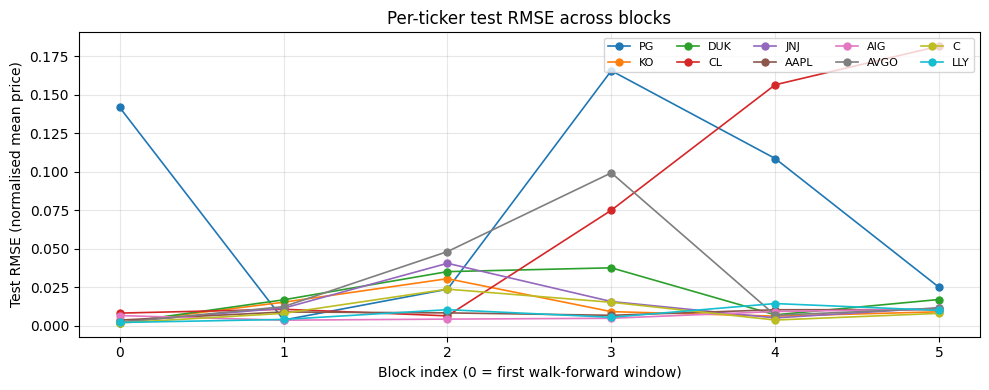

In [63]:
test_rmse = rmse[:, 2, :]   # phase index 2 = test
test_valid = valid[:, 2, :]
prior_train_days = np.arange(n_blocks_run) * BLOCK_STEP  # feature rows seen before each block

stockperformance = np.nanmean(test_rmse, axis=1)
# Next Find indices of 5 best and worst performers
bottom5_idx = np.argsort(stockperformance)[-5:][::-1]
top5_idx = np.argsort(stockperformance)[:5]
bottom5_labels = [labels[i] for i in bottom5_idx]
top5_labels = [labels[i] for i in top5_idx]


fig, ax = plt.subplots(figsize=(10, 4))
for i, sym in enumerate(top5_labels+bottom5_labels): #here I wanna pick the 5 best and 5 worst performers to plot out
    v = test_valid[i]
    ax.plot(np.where(v)[0], test_rmse[i, v], "o-", ms=5, lw=1.2, label=sym)
ax.set_xlabel("Block index (0 = first walk-forward window)")
ax.set_ylabel("Test RMSE (normalised mean price)")
ax.set_title("Per-ticker test RMSE across blocks")
ax.legend(ncol=5, fontsize=8, loc="upper right")
ax.grid(alpha=0.3)
plt.tight_layout()
save_fig(fig, 5, "per_ticker_test_rmse_by_block")

'figs/SP100/multislice_demo/06_best_worst_performer_prices.png'

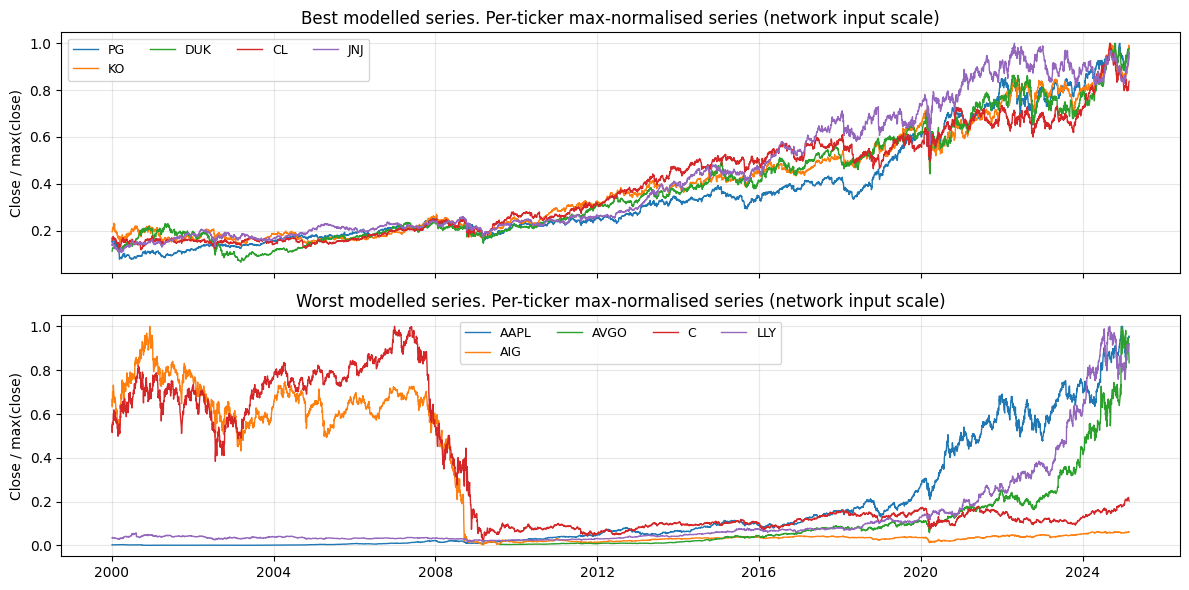

In [64]:
#OK, what is goin on with the best and the worst performers?

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
for sym in top5_labels:
    s = df_raw[sym].dropna()
    axes[0].plot(s.index.map(lambda i: df_raw.loc[i, "Date"]), s / s.max(), label=sym, lw=1)
axes[0].set_ylabel("Close / max(close)")
axes[0].set_title("Best modelled series. Per-ticker max-normalised series (network input scale)")
axes[0].legend(ncol=4, fontsize=9)
axes[0].grid(alpha=0.3)

for sym in bottom5_labels:
    s = df_raw[sym].dropna()
    axes[1].plot(s.index.map(lambda i: df_raw.loc[i, "Date"]), s / s.max(), label=sym, lw=1)
axes[1].set_ylabel("Close / max(close)")
axes[1].set_title("Worst modelled series. Per-ticker max-normalised series (network input scale)")
axes[1].legend(ncol=4, fontsize=9)
axes[1].grid(alpha=0.3)
plt.tight_layout()

save_fig(fig, 6, "best_worst_performer_prices")

'figs/SP100/multislice_demo/07_aggregate_test_error_vs_block.png'

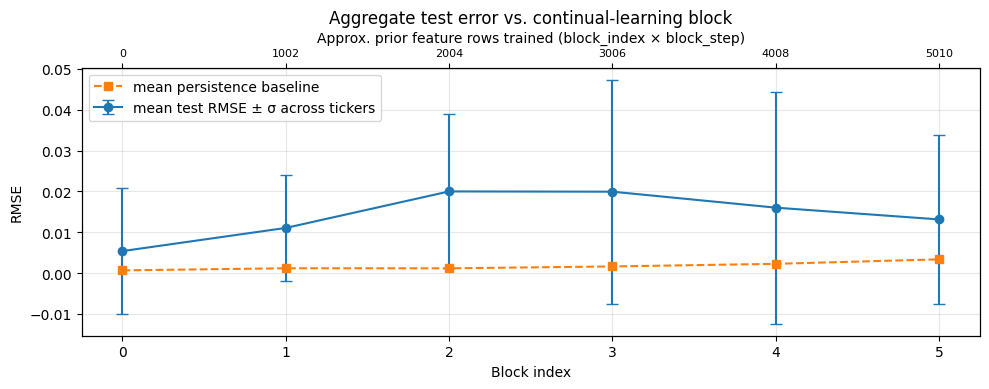

In [65]:
mean_by_block = np.nanmean(test_rmse, axis=0)
std_by_block = np.nanstd(test_rmse, axis=0)
pers_mean = np.nanmean(pers[:, 2, :], axis=0)

fig, ax1 = plt.subplots(figsize=(10, 4))
x = np.arange(n_blocks_run)
ax1.errorbar(x, mean_by_block, yerr=std_by_block, fmt="o-", capsize=4, color="C0", label="mean test RMSE ± σ across tickers")
ax1.plot(x, pers_mean, "s--", color="C1", label="mean persistence baseline")
ax1.set_xlabel("Block index")
ax1.set_ylabel("RMSE")
ax1.set_title("Aggregate test error vs. continual-learning block")
ax1.legend()
ax1.grid(alpha=0.3)

ax2 = ax1.twiny()
ax2.set_xlim(ax1.get_xlim())
ax2.set_xticks(x)
ax2.set_xticklabels([f"{int(d)}" for d in prior_train_days], fontsize=8)
ax2.set_xlabel("Approx. prior feature rows trained (block_index × block_step)")
plt.tight_layout()
save_fig(fig, 7, "aggregate_test_error_vs_block")


'figs/SP100/multislice_demo/08_test_rmse_heatmap_tickers_blocks.png'

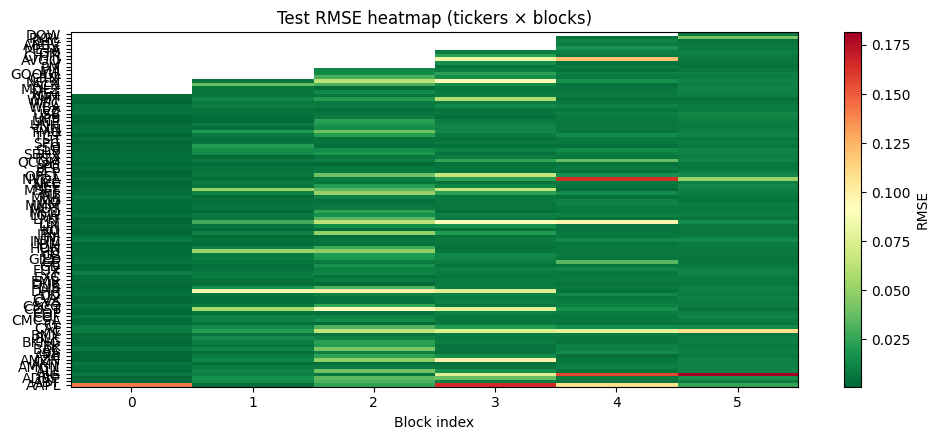

In [66]:
fig, ax = plt.subplots(figsize=(10, 4.5))
im = ax.imshow(test_rmse, aspect="auto", cmap="RdYlGn_r", origin="lower")  # green to red (reversed)
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels)
ax.set_xticks(range(n_blocks_run))
ax.set_xlabel("Block index")
ax.set_title("Test RMSE heatmap (tickers × blocks)")
plt.colorbar(im, ax=ax, label="RMSE")
plt.tight_layout()
save_fig(fig, 8, "test_rmse_heatmap_tickers_blocks")

## 6. Cross-stock comparison on the ticker sample

Summarise **mean test RMSE over all blocks** and check dispersion. Consumer staples (KO, PG) often show
lower error than volatile tech / industrial names; crisis-era blocks inflate error for cyclicals.

,ticker,mean_test_rmse,std_test_rmse,max_test_rmse,mean_persistence,beats_persistence
61,PG,0.0043,0.0019,0.0073,0.0013,0.0
43,KO,0.0046,0.0017,0.0076,0.0014,0.0
28,DUK,0.0054,0.0021,0.0080,0.0016,0.0
17,CL,0.0054,0.0018,0.0079,0.0015,0.0
41,JNJ,0.0056,0.0023,0.0097,0.0016,0.0
...,...,...,...,...,...,...
45,LLY,0.0492,0.0362,0.0971,0.0010,0.0
15,C,0.0595,0.0341,0.1091,0.0021,0.0
90,AVGO,0.0701,0.0472,0.1207,0.0013,0.0
3,AIG,0.0730,0.0721,0.1814,0.0013,0.0


'figs/SP100/multislice_demo/09_cross_sectional_mean_test_rmse.png'

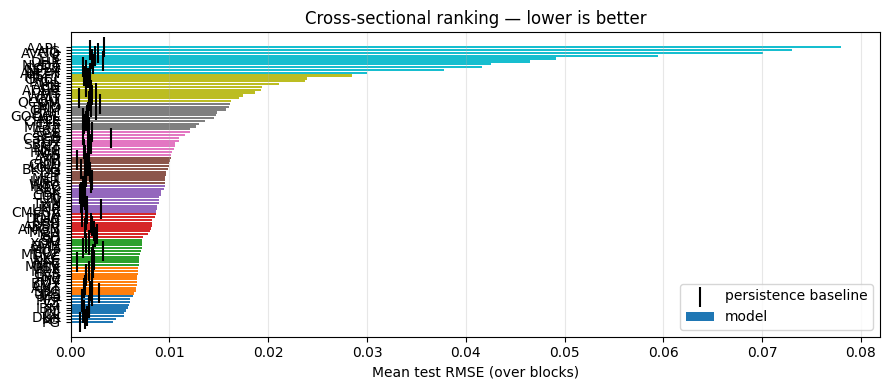

In [67]:
summary_rows = []
for i, sym in enumerate(labels):
    m = test_valid[i]
    summary_rows.append({
        "ticker": sym,
        "mean_test_rmse": float(np.nanmean(test_rmse[i, m])),
        "std_test_rmse": float(np.nanstd(test_rmse[i, m])),
        "max_test_rmse": float(np.nanmax(test_rmse[i, m])),
        "mean_persistence": float(np.nanmean(pers[i, 2, m])),
        "beats_persistence": float(np.nanmean(test_rmse[i, m] < pers[i, 2, m])),
    })
summary = pd.DataFrame(summary_rows).sort_values("mean_test_rmse")
display(summary.round(4))

fig, ax = plt.subplots(figsize=(9, 4))
colors = plt.cm.tab10(np.linspace(0, 1, len(summary)))
ax.barh(summary["ticker"], summary["mean_test_rmse"], color=colors, label="model")
ax.scatter(summary["mean_persistence"], summary.index, marker="|", s=200, c="k", zorder=3, label="persistence baseline")
ax.set_xlabel("Mean test RMSE (over blocks)")
ax.set_title("Cross-sectional ranking — lower is better")
ax.legend(loc="lower right")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
save_fig(fig, 9, "cross_sectional_mean_test_rmse")


In [68]:
# Where does each ticker hurt most? (block of max test RMSE)
worst = []
for i, sym in enumerate(labels):
    m = test_valid[i]
    blocks = np.where(m)[0]
    vals = test_rmse[i, m]
    j = np.argmax(vals)
    b = blocks[j]
    sl = calendar_start + b * BLOCK_STEP - per_ticker[sym]["first_valid_feat_row"]
    d0 = ref_dates.iloc[sl].date() if 0 <= sl < len(ref_dates) else "?"
    worst.append({"ticker": sym, "worst_block": int(b), "test_rmse": float(vals[j]), "period_start": d0})
pd.DataFrame(worst).sort_values("test_rmse", ascending=False)

,ticker,worst_block,test_rmse,period_start
3,AIG,5,0.181445,2019-12-10
0,AAPL,3,0.165534,2011-12-21
57,NVDA,4,0.163313,2015-12-16
90,AVGO,4,0.120710,2006-05-18
15,C,5,0.109108,2019-12-10
...,...,...,...,...
68,T,4,0.008106,2015-12-16
28,DUK,3,0.008046,2011-12-21
17,CL,3,0.007913,2011-12-21
43,KO,5,0.007567,2019-12-10


## 6b. Test prediction and uncertainty (BA)

After a multislice run, model outputs live in the concatenated ``netw1_outpop_*_dist.bin`` streams — one logged row per scored step, in block / phase / ticker order (warmup replay steps are omitted). ``Display.stitch_multislice_ticker`` inverts that layout for a single symbol; ``Display.plot_multislice_prediction(..., phases="test")`` returns ``(fig, ax, rmses)`` so the plot can be adjusted in the notebook before saving; it draws only the **unseen/test** decoded mean with central credible bands (same convention as ``plot_general_prediction``).


BA: 894 test steps across 6 blocks
RMSE test = 0.008849  persistence = 0.003126


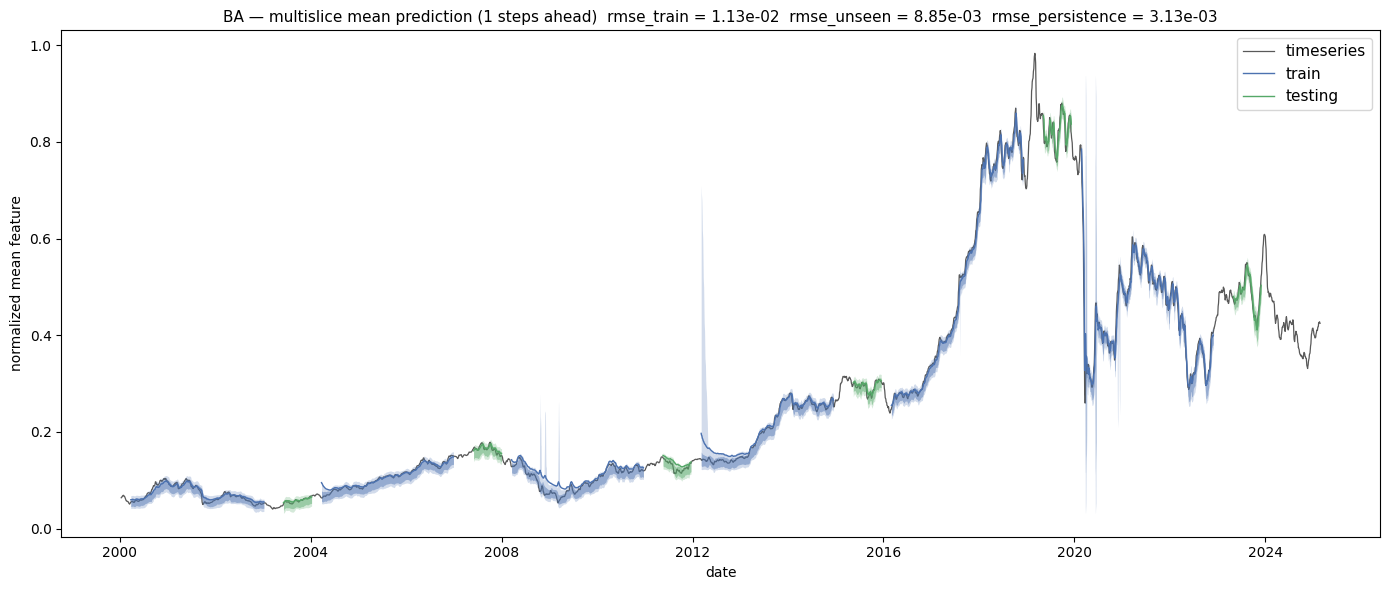

In [85]:
# Stitched walk-forward test predictions + uncertainty bands
for m in (Utils, FG, Mains, Display):
    importlib.reload(m)

sym = "BA"
sym_dates = df_raw["Date"].iloc[
    per_ticker[sym]["first_valid_feat_row"]:
    per_ticker[sym]["first_valid_feat_row"] + per_ticker[sym]["feats"].shape[0]
]

series_sym = Display.stitch_multislice_ticker(PARAMFILE, sym)
test_pts = int((series_sym["phase"] == 2).sum())
print(f"{sym}: {test_pts} test steps across "
      f"{series_sym['block'].max() + 1} blocks")

fig, ax, rmse_sym = Display.plot_multislice_prediction(
    PARAMFILE,
    sym,
    phases=["test", "train"],
    confidence_levels=(0.7, 0.9),
    dates=sym_dates.values,
    series=series_sym,
)

# Adjust figure in-place before saving (examples):
# ax.set_xlim(sym_dates.iloc[-800], sym_dates.iloc[-1])
# ax.set_title(f"{sym} — walk-forward test predictions")

fig.tight_layout()
#ax.set_xlim(18100,19600)
save_fig(fig, 13, f"multislice_prediction_{sym}")
print(f"RMSE test = {rmse_sym[2]:.4g}  persistence = {rmse_sym[3]:.4g}")

Parameter sweep: 6 combinations to run
  [1/6] {'offs': 1, 'K': 2, 'K_mode': 'logarithmic', 'mean_nbin': 120, 'deriv1st_nbin': 2, 'taumax': 50} -> rmse_unseen = 4.9736e-03  (200.0s, ~16m39s left)
  [2/6] {'offs': 1, 'K': 4, 'K_mode': 'logarithmic', 'mean_nbin': 120, 'deriv1st_nbin': 2, 'taumax': 50} -> rmse_unseen = 6.6003e-03  (273.3s, ~15m46s left)
  [3/6] {'offs': 1, 'K': 6, 'K_mode': 'logarithmic', 'mean_nbin': 120, 'deriv1st_nbin': 2, 'taumax': 50} -> rmse_unseen = 7.3255e-03  (376.0s, ~14m09s left)
  [4/6] {'offs': 1, 'K': 8, 'K_mode': 'logarithmic', 'mean_nbin': 120, 'deriv1st_nbin': 2, 'taumax': 50} -> rmse_unseen = 7.8215e-03  (540.8s, ~11m35s left)
  [5/6] {'offs': 1, 'K': 10, 'K_mode': 'logarithmic', 'mean_nbin': 120, 'deriv1st_nbin': 2, 'taumax': 50} -> rmse_unseen = 8.2422e-03  (536.5s, ~6m25s left)
  [6/6] {'offs': 1, 'K': 15, 'K_mode': 'logarithmic', 'mean_nbin': 120, 'deriv1st_nbin': 2, 'taumax': 50} -> rmse_unseen = 8.9897e-03  (875.7s, ~0m00s left)
  Saved: figs/SP100

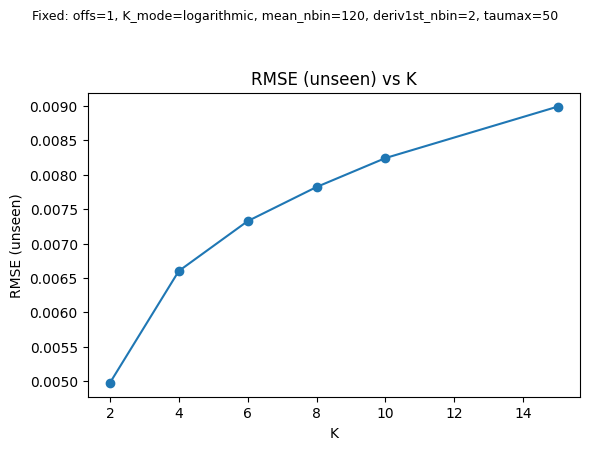

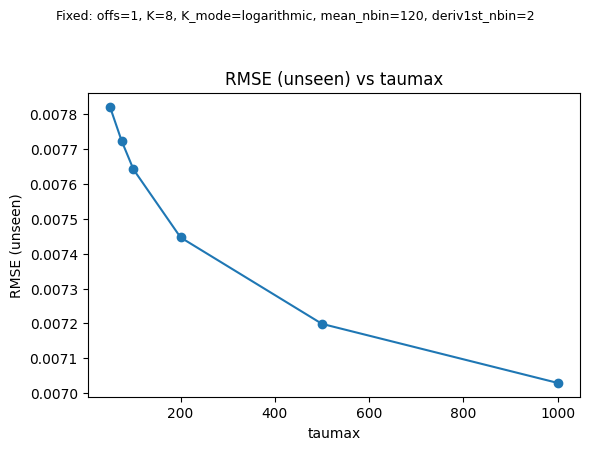

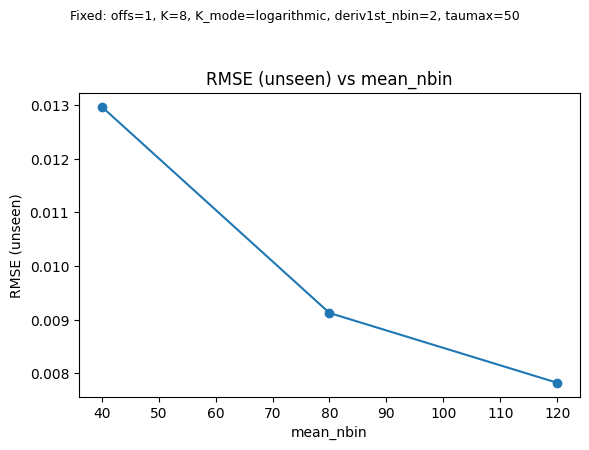

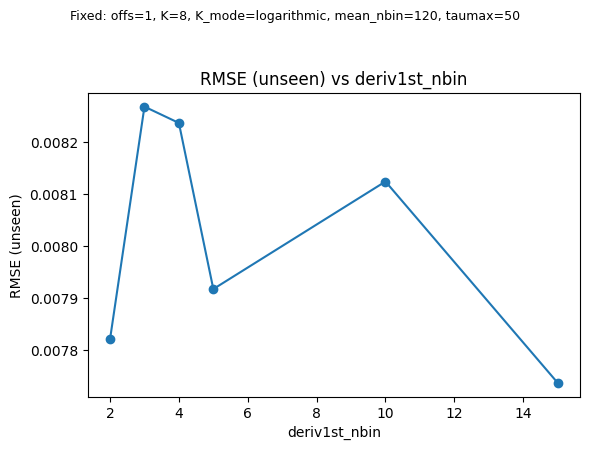

In [ ]:
## 7. Picking the right time constant after the much more complicated schedule now

# Utils.multislice_for_sweep returns the analyze dict; pick outcome with metric=.
# Options: rmse_unseen (default), rmse_train, rmse_validation, rmse_persistence,
#          quadratic_loss, smooth_loss, tick_loss, firm_loss.
SWEEP_RUN_KWARGS = {"figno": 0, "verbose": False, "var_level": 0.95}


#Define the Sweep
sweep_spec = { # --- Define parameter values to sweep  ---
    "offs":          [1], #Next day prediction
    "K":             [2,4,6,8,10,12,15,20], #range from evo search: 2-20
    "K_mode":        ["logarithmic"], #"linear", "logarithmic" free choice of linear or logarithmic mode 
    "mean_nbin":     [150], #range from evo search: 2-100
    "deriv1st_nbin": [2], #range from evo search: 2-100
    "taumax":        [500]#range from evo search: 1-1500  
    }
#Run the Sweep
results = Utils.param_sweep(
    sweep_spec,
    default_paramfile="Parameters_multislice.par",  # see note below
    paramfile="Parameters.par",
    run_fn=Utils.multislice_for_sweep,
    run_kwargs=SWEEP_RUN_KWARGS,
    metric="rmse_unseen",
)
#Plot the Sweep
Display.plot_sweep_heatmaps(results, sweep_spec, savepath="figs/SP100/multislice_demo/")



#Define the Sweep
sweep_spec = { # --- Define parameter values to sweep  ---
    "offs":          [1], #Next day prediction
    "K":             [12], #range from evo search: 2-20
    "K_mode":        ["logarithmic"], #"linear", "logarithmic" free choice of linear or logarithmic mode 
    "mean_nbin":     [150], #range from evo search: 2-100
    "deriv1st_nbin": [2], #range from evo search: 2-100
    "taumax":        [50,200,500,800,1200]#range from evo search: 1-1500  
    }
#Run the Sweep
results = Utils.param_sweep(
    sweep_spec,
    default_paramfile="Parameters_multislice.par",  # see note below
    paramfile="Parameters.par",
    run_fn=Utils.multislice_for_sweep,
    run_kwargs=SWEEP_RUN_KWARGS,
    metric="rmse_unseen",
)
#Plot the Sweep
Display.plot_sweep_heatmaps(results, sweep_spec, savepath="figs/SP100/multislice_demo/")

#Define the Sweep
sweep_spec = { # --- Define parameter values to sweep  ---
    "offs":          [1], #Next day prediction
    "K":             [12], #range from evo search: 2-20
    "K_mode":        ["logarithmic"], #"linear", "logarithmic" free choice of linear or logarithmic mode 
    "mean_nbin":     [10,50,150], #range from evo search: 2-100
    "deriv1st_nbin": [2], #range from evo search: 2-100
    "taumax":        [500]#range from evo search: 1-1500  
    }
#Run the Sweep
results = Utils.param_sweep(
    sweep_spec,
    default_paramfile="Parameters_multislice.par",  # see note below
    paramfile="Parameters.par",
    run_fn=Utils.multislice_for_sweep,
    run_kwargs=SWEEP_RUN_KWARGS,
    metric="rmse_unseen",
)
#Plot the Sweep
Display.plot_sweep_heatmaps(results, sweep_spec, savepath="figs/SP100/multislice_demo/")

#Define the Sweep
sweep_spec = { # --- Define parameter values to sweep  ---
    "offs":          [1], #Next day prediction
    "K":             [12], #range from evo search: 2-20
    "K_mode":        ["logarithmic"], #"linear", "logarithmic" free choice of linear or logarithmic mode 
    "mean_nbin":     [150], #range from evo search: 2-100
    "deriv1st_nbin": [2,3,4,5,10,15], #range from evo search: 2-100
    "taumax":        [500]#range from evo search: 1-1500  
    }
#Run the Sweep
results = Utils.param_sweep(
    sweep_spec,
    default_paramfile="Parameters_multislice.par",  # see note below
    paramfile="Parameters.par",
    run_fn=Utils.multislice_for_sweep,
    run_kwargs=SWEEP_RUN_KWARGS,
    metric="rmse_unseen",
)
#Plot the Sweep
Display.plot_sweep_heatmaps(results, sweep_spec, savepath="figs/SP100/multislice_demo/")




## 8. Ticker count sweep

How does mean test error change when more full-history SP100 names are included? `Utils.ticker_count_sweep()` grows the `tickers` list from a sorted pool of 81 symbols that share the same calendar (late-IPO names with leading `NaN`s are excluded). Pattern counts stay fixed; only the number of concatenated ticker streams changes. With `warmup_pat > 0`, more tickers mean more ticker-to-ticker transitions per phase (each `k > 0` segment pays a warmup replay before scored steps).


In [20]:
# Ticker-count sweep: add more full-history stocks (exclude late IPOs). About 36min runtime at 15/40/20
for m in (Utils, FG, Mains, Display):
    importlib.reload(m)

N_TICKERS_SWEEP = [2,5,10,20,40,80,98]

ticker_out = Utils.ticker_count_sweep(
    N_TICKERS_SWEEP,
    default_paramfile=PARAMFILE,
    paramfile="Parameters_multislice_ntickers_work.par",
    run_kwargs={"exefile": "./ltslmain", "verbose": False},
)

Ticker-count sweep: 7 values, pool=98 tickers (fixed pats 750/52/200)
  [1/7] n_tickers=2  rmse_test=8.6212e-02  (23.4s, ~2m20s left)
  [2/7] n_tickers=5  rmse_test=3.5821e-02  (54.1s, ~3m13s left)
  [3/7] n_tickers=10  rmse_test=2.9683e-02  (107.6s, ~4m06s left)
  [4/7] n_tickers=20  rmse_test=1.5228e-02  (214.5s, ~4m59s left)
  [5/7] n_tickers=40  rmse_test=1.0816e-02  (424.9s, ~5m29s left)
  [6/7] n_tickers=80  rmse_test=1.0026e-02  (850.7s, ~4m39s left)
  [7/7] n_tickers=98  rmse_test=9.1857e-03  (959.1s, ~0m00s left)


  Saved: figs/SP100/multislice_demo/14_ticker_sweep_test_rmse_vs_n_tickers.png


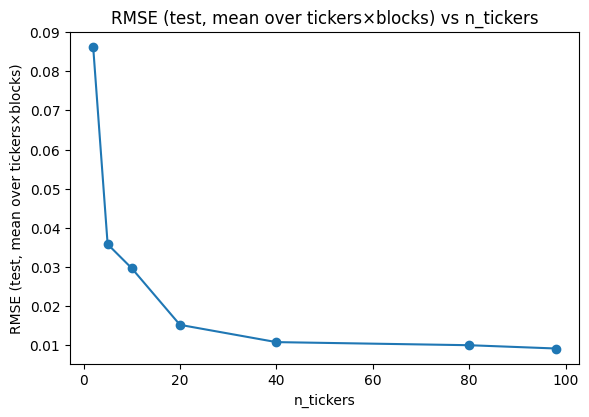

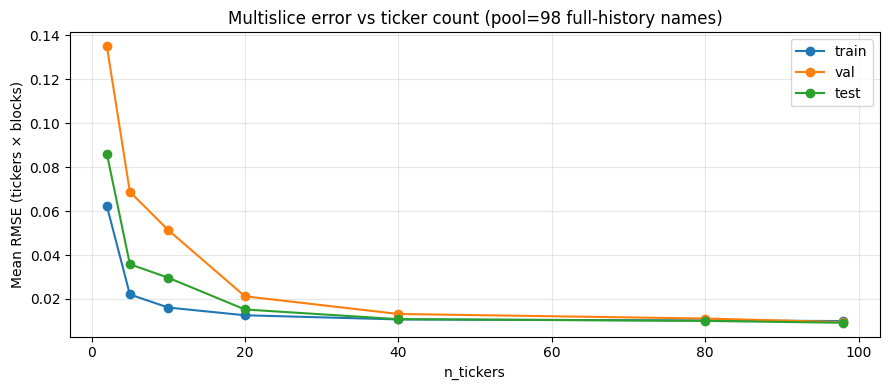

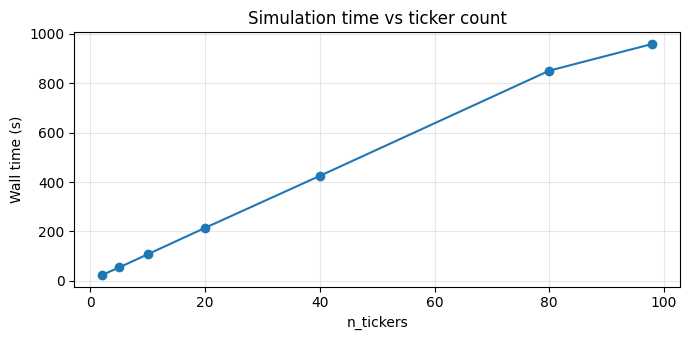

,n_tickers,actual_n_tickers,tickers,rmse_train,rmse_val,rmse_test,rmse_persistence,elapsed_s
0,2,2,"AAPL,ABT",0.062371,0.135072,0.086212,0.001249,23.436482
1,5,5,"AAPL,ABT,ADBE,AIG,ALL",0.022056,0.068782,0.035821,0.001010,54.124830
2,10,10,"AAPL,ABT,ADBE,AIG,ALL,AMGN,AMT,AMZN,AXP,BA",0.016106,0.051383,0.029683,0.000925,107.605443
3,20,20,"AAPL,ABT,ADBE,AIG,ALL,AMGN,AMT,AMZN,AXP,BA,BAC...",0.012591,0.021230,0.015228,0.001011,214.508158
4,40,40,"AAPL,ABT,ADBE,AIG,ALL,AMGN,AMT,AMZN,AXP,BA,BAC...",0.010702,0.013188,0.010816,0.001175,424.932568
5,80,80,"AAPL,ABT,ADBE,AIG,ALL,AMGN,AMT,AMZN,AXP,BA,BAC...",0.010240,0.011099,0.010026,0.001105,850.668251
6,98,98,"AAPL,ABT,ADBE,AIG,ALL,AMGN,AMT,AMZN,AXP,BA,BAC...",0.009955,0.009476,0.009186,0.001152,959.139392


In [21]:
sweep_spec = {"n_tickers": N_TICKERS_SWEEP}
Display.plot_sweep_heatmaps(
    ticker_out["results"],
    sweep_spec,
    metric_label="RMSE (test, mean over tickers×blocks)",
    save_as=figpath(14, "ticker_sweep_test_rmse_vs_n_tickers"),
)

ticker_details = pd.DataFrame(ticker_out["details"])
fig, ax = plt.subplots(figsize=(9, 4))
for col, label in [("rmse_train", "train"), ("rmse_val", "val"), ("rmse_test", "test")]:
    ax.plot(ticker_details["n_tickers"], ticker_details[col], "o-", label=label)
ax.set_xlabel("n_tickers")
ax.set_ylabel("Mean RMSE (tickers × blocks)")
ax.set_title(f"Multislice error vs ticker count (pool={ticker_out['n_pool']} full-history names)")
#ax.set_ylim(0.025,0.105)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
save_fig(fig, 15, "ticker_sweep_rmse_phases")
plt.show()

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(ticker_details["n_tickers"], ticker_details["elapsed_s"], "o-")
ax.set_xlabel("n_tickers")
ax.set_ylabel("Wall time (s)")
ax.set_title("Simulation time vs ticker count")
ax.grid(alpha=0.3)
plt.tight_layout()
save_fig(fig, 16, "ticker_sweep_elapsed_time")
plt.show()
display(ticker_details)


## 8. Block-count sweep

How does mean test error change when the same calendar timeline is split into more or fewer walk-forward blocks? Utils.block_sweep() scales trnpat, vanpat, and tenpat together (fixed phase ratios) so that n_blocks × block_step ≈ calendar_span. When warmup_pat > 0, very large n_blocks values may be skipped because each scaled phase must stay longer than warmup_pat + offs.





In [ ]:
# Block-count sweep: scale trnpat/vanpat/tenpat to fit n_blocks on the calendar
for m in (Utils, FG, Mains, Display):
    importlib.reload(m)

N_BLOCKS_SWEEP = [1,2,3,4,6,8,10,15] # more blocks(even shorter test phases) would encroach on the warmup phase

block_out = Utils.block_sweep(
    N_BLOCKS_SWEEP,
    default_paramfile=PARAMFILE,
    paramfile="Parameters_multislice_nblocks_work.par",
    run_kwargs={"exefile": "./ltslmain", "verbose": False},
)

sweep_spec = {"n_blocks": N_BLOCKS_SWEEP}
Display.plot_sweep_heatmaps(
    block_out["results"],
    sweep_spec,
    metric_label="RMSE (test, mean over tickers×blocks)",
    save_as=figpath(10, "block_sweep_test_rmse_vs_n_blocks"),
)

details = pd.DataFrame(block_out["details"])
fig, ax = plt.subplots(figsize=(9, 4))
for col, label in [("rmse_train", "train"), ("rmse_val", "val"), ("rmse_test", "test")]:
    ax.plot(details["n_blocks"], details[col], "o-", label=label)
ax.set_xlabel("n_blocks")
ax.set_ylabel("Mean RMSE (tickers × blocks)")
ax.set_title(f"Multislice error vs block count (calendar_span={block_out['calendar_span']})")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
save_fig(fig, 11, "block_sweep_rmse_phases")
plt.show()

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(details["n_blocks"], details["elapsed_s"], "o-")
ax.set_xlabel("n_blocks")
ax.set_ylabel("Wall time (s)")
ax.set_title("Simulation time vs block count")
ax.grid(alpha=0.3)
plt.tight_layout()
save_fig(fig, 12, "block_sweep_elapsed_time")
plt.show()

display(details)


## 9. Volatility persistence in the 1st-derivative feature

Besides the fact that we need only very few temporal kernels, evidently the 1st derivative is also largely useless for predicting the next day, particularly when the model is supposed to be market-universal (across all tickers). A side-question that the RBF encoding lets us answer directly: **how predictable is the 1st-derivative
feature (col 1, the day-to-day price change) one step ahead?** 

My intuition to test based on Martins previous analysis is this: large moves should predict large moves the next day (**volatility clustering**), while the *sign* of the move need not carry over on a daily timescale. 

To test this I re-encoded that feature at high
resolution (**100 bins**) and build a lag-1 *transition correlogram* — the conditional probability of
tomorrow's active bin given today's active bin, P(bin_{t+1} = j | bin_t = i).

To make the question comparable across tickers, each ticker's 1st derivative is z-scored by its own
standard deviation and clipped to ±4σ, so the **centre bin ≈ "no change"** and extreme bins are large
up/down moves. I generated a few different views on this:

- the raw conditional probability P(next | today), and
- the **lift** P(next | today) / P(next) (log2): values > 0 mean a transition is *more* likely than if
  consecutive days were independent.

  - **Magnitude:** mass shifts away from the central cross toward the high-|σ| bins on *both* axes ⇒ big
  moves follow big moves. Quantified by the lag-1 autocorrelation of |Δ|.
- **Direction:** *where* that off-centre mass sits tells us about sign. The **main-diagonal** corners
  (+,+ and −,−) mean the sign is preserved; the **anti-diagonal** corners (+,− and −,+) mean it
  reverses; brightening in all four corners would mean the sign is irrelevant (the "no memory" case, with
  P(same sign) ≈ 0.5).

I checked one ticker (AAPL) first, then pooled the statistic over every ticker. As the plots show, on
this dataset the 1st-derivative channel is strongly **volatility-persistent** *and* strongly
**sign-reverting** at lag 1 (a big up day is typically followed by a big down day) — so the lift mass
lands on the anti-diagonal and P(same sign) sits well below 0.5, an even sharper version of the original
"direction doesn't carry over" intuition.

'figs/SP100/multislice_demo/18_deriv_persistence_AAPL.png'

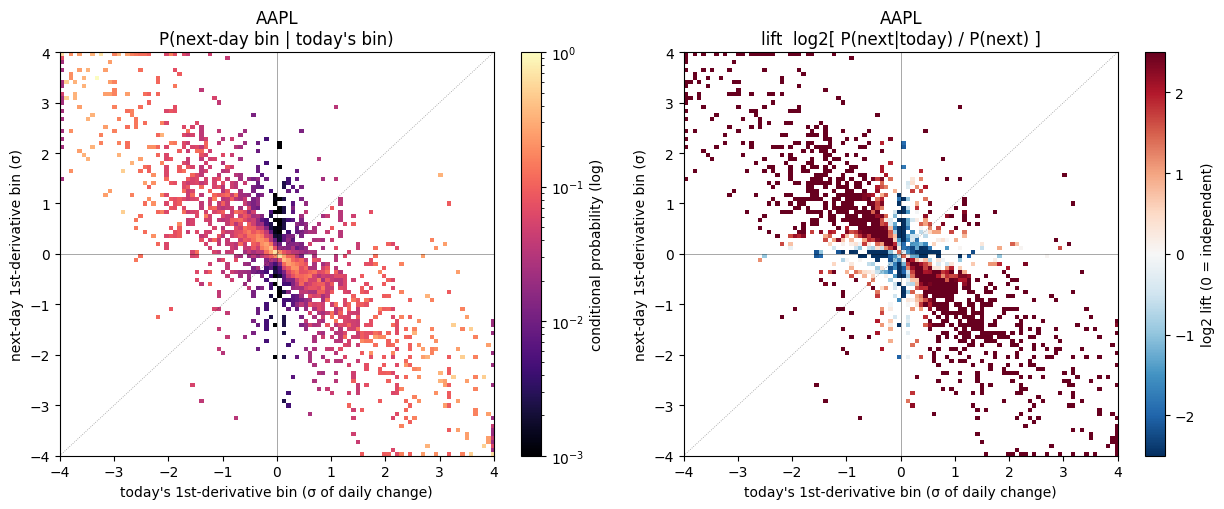

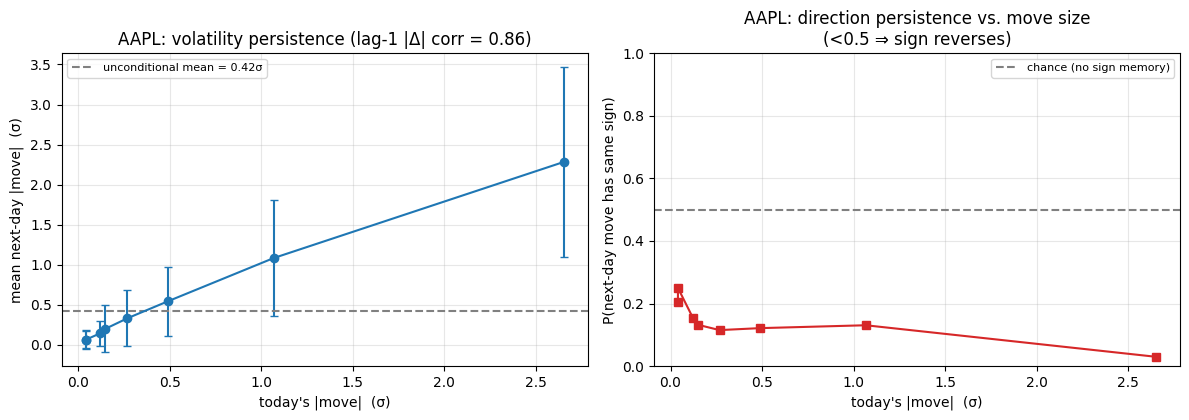

In [ ]:
#New Analysis: high-resolution lag-1 transition correlogram of the 1st-derivative feature
#
# Encode col 1 (daily change) into 100 bins and ask: given today's active bin, what is the
# distribution over tomorrow's active bin?  Bins are z-scored per ticker (units of that
# ticker's daily-change sigma, clipped to +/-LIM) so the centre bin ~= "no change" and the
# analysis is comparable across tickers.
import importlib
from matplotlib.colors import LogNorm
for m in (FG, RBFBinner):
    importlib.reload(m)

DERIV_NBIN = 100                       # high-resolution bins for the 1st derivative
LIM = 4.0                              # clip range, in standard deviations of daily change
deriv_centers = np.linspace(-LIM, LIM, DERIV_NBIN)
deriv_enc = RBFBinner.Encoder1D(-LIM, LIM, DERIV_NBIN, 2.0 * LIM / DERIV_NBIN)

# Per-ticker features are built in section 2; reload if this cell is run standalone.
if "per_ticker" not in globals():
    per_ticker, csv_lens = FG.load_tickers_features("sp100_daily_prices.csv", ",".join(TICKERS))


def active_deriv_bins(sym):8 or None if degenerate."""
    d1 = np.asarray(per_ticker[sym]["feats"][:, 1], dtype=float)
    d1 = d1[np.isfinite(d1)]
    sd = d1.std()
    if d1.size < 50 or sd == 0:
        return None
    z = np.clip(d1 / sd, -LIM, LIM)
    return deriv_enc.encode(z).argmax(axis=1)


def transition_counts(bins, n_bins=DERIV_NBIN):
    """Lag-1 transition counts C[i, j] = #(bin_t = i -> bin_{t+1} = j)."""
    C = np.zeros((n_bins, n_bins), dtype=float)
    np.add.at(C, (bins[:-1], bins[1:]), 1.0)
    return C


def conditional_and_lift(C):
    """Row-normalised P(next | today) and lift = P(next | today) / P(next)."""
    row = C.sum(axis=1, keepdims=True)
    P = np.divide(C, row, out=np.full_like(C, np.nan), where=row > 0)
    marg = C.sum(axis=0)
    marg = marg / marg.sum()
    with np.errstate(divide="ignore", invalid="ignore"):
        lift = P / marg[None, :]
    return P, lift


def split_pairs(bins):
    """(today_mag, next_mag, today_sign, next_sign) for every lag-1 step (sigma units)."""
    sgn = np.sign(deriv_centers)[bins]
    mag = np.abs(deriv_centers)[bins]
    return mag[:-1], mag[1:], sgn[:-1], sgn[1:]


def persistence_curves(mt, mn, st, sn, nq=12):
    """Bin by today's |move| (quantiles); return mean next-day |move|, its std, and P(same sign)."""
    qs = np.unique(np.quantile(mt, np.linspace(0, 1, nq + 1)))
    which = np.digitize(mt, qs[1:-1])
    x, y, e, psame = [], [], [], []
    for k in range(len(qs) - 1):
        sel = which == k
        if not sel.any():
            continue
        x.append(mt[sel].mean())
        y.append(mn[sel].mean())
        e.append(mn[sel].std())
        psame.append((st[sel] == sn[sel]).mean())
    return map(np.asarray, (x, y, e, psame))


def plot_transition(P, lift, title, fig_no, stem):
    """Side-by-side conditional-probability and log2-lift correlograms (x=today, y=next-day)."""
    extent = [-LIM, LIM, -LIM, LIM]
    fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.2))
    im0 = axes[0].imshow(P.T, origin="lower", aspect="auto", extent=extent, cmap="magma",
                         norm=LogNorm(vmin=1e-3, vmax=np.nanmax(P)))
    axes[0].set_title(f"{title}\nP(next-day bin | today's bin)")
    fig.colorbar(im0, ax=axes[0], label="conditional probability (log)")

    log2lift = np.log2(np.where(lift > 0, lift, np.nan))
    im1 = axes[1].imshow(log2lift.T, origin="lower", aspect="auto", extent=extent,
                         cmap="RdBu_r", vmin=-2.5, vmax=2.5)
    axes[1].set_title(f"{title}\nlift  log2[ P(next|today) / P(next) ]")
    fig.colorbar(im1, ax=axes[1], label="log2 lift (0 = independent)")
    for ax in axes:
        ax.axhline(0, color="k", lw=0.6, alpha=0.4)
        ax.axvline(0, color="k", lw=0.6, alpha=0.4)
        ax.plot([-LIM, LIM], [-LIM, LIM], "k:", lw=0.6, alpha=0.4)
        ax.set_xlabel("today's 1st-derivative bin (σ of daily change)")
        ax.set_ylabel("next-day 1st-derivative bin (σ)")
    plt.tight_layout()
    save_fig(fig, fig_no, stem)
    return fig


# ---- Single-ticker example: AAPL ----
sym = "AAPL"
bins_sym = active_deriv_bins(sym)
C_sym = transition_counts(bins_sym)
P_sym, lift_sym = conditional_and_lift(C_sym)
plot_transition(P_sym, lift_sym, sym, 17, f"deriv_transition_{sym}")

mt, mn, st, sn = split_pairs(bins_sym)
x, y, e, psame = persistence_curves(mt, mn, st, sn)
base = mn.mean()                                   # unconditional mean next-day |move|
r_vol = np.corrcoef(mt, mn)[0, 1]                  # lag-1 volatility autocorrelation

fig, axes = plt.subplots(1, 2, figsize=(12, 4.3))
axes[0].errorbar(x, y, yerr=e, fmt="o-", capsize=3, color="C0")
axes[0].axhline(base, ls="--", color="grey", label=f"unconditional mean = {base:.2f}σ")
axes[0].set_xlabel("today's |move|  (σ)")
axes[0].set_ylabel("mean next-day |move|  (σ)")
axes[0].set_title(f"{sym}: volatility persistence (lag-1 |Δ| corr = {r_vol:.2f})")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

axes[1].plot(x, psame, "s-", color="C3")
axes[1].axhline(0.5, ls="--", color="grey", label="chance (no sign memory)")
axes[1].set_ylim(0, 1)
axes[1].set_xlabel("today's |move|  (σ)")
axes[1].set_ylabel("P(next-day move has same sign)")
axes[1].set_title(f"{sym}: direction persistence vs. move size\n(<0.5 ⇒ sign reverses)")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)
plt.tight_layout()
save_fig(fig, 18, f"deriv_persistence_{sym}")

Pooled 98 tickers, 582,957 lag-1 transitions
Volatility autocorrelation: mean=0.814, 100% of tickers positive
Sign persistence after large move: mean=0.066 (0.5 = no daily-scale directional memory)


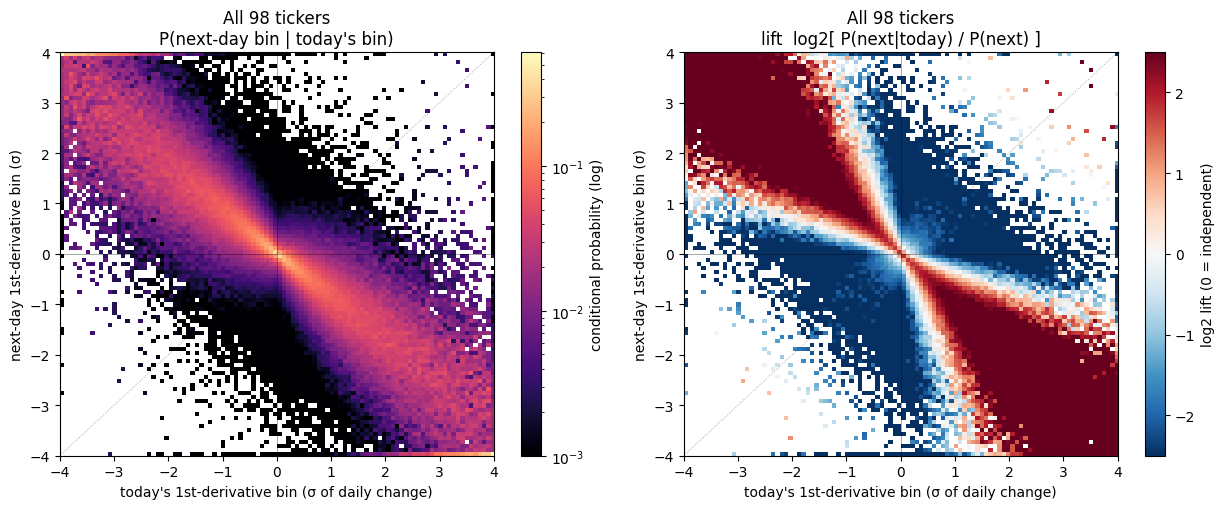

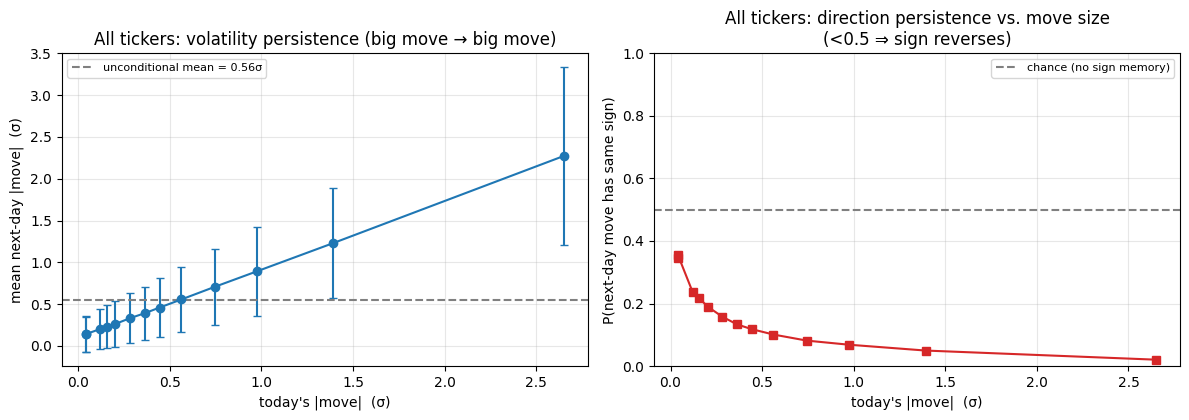

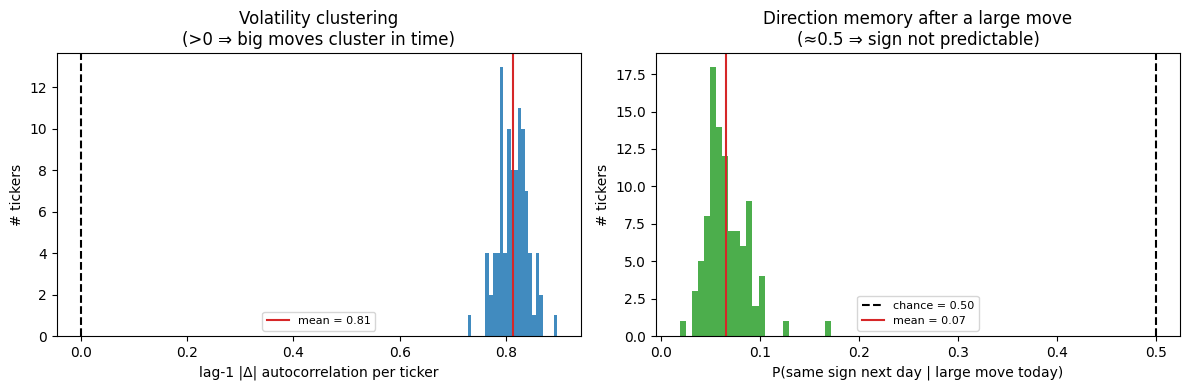

In [44]:
# Pool the same statistics over every ticker (transitions never cross ticker boundaries).
C_all = np.zeros((DERIV_NBIN, DERIV_NBIN))
mt_all, mn_all, st_all, sn_all = [], [], [], []
vol_autocorr, sign_big = [], []
used = []
for s in per_ticker:
    bins = active_deriv_bins(s)
    if bins is None:
        continue
    C_all += transition_counts(bins)
    a, b, c, d = split_pairs(bins)
    mt_all.append(a); mn_all.append(b); st_all.append(c); sn_all.append(d)
    if a.std() > 0 and b.std() > 0:
        vol_autocorr.append(np.corrcoef(a, b)[0, 1])      # lag-1 volatility clustering
    thr = np.quantile(a, 2 / 3)                            # "large" move = top tercile for this ticker
    big = a >= thr
    if big.any():
        sign_big.append((c[big] == d[big]).mean())         # sign carry-over after a large move
    used.append(s)

mt_all = np.concatenate(mt_all); mn_all = np.concatenate(mn_all)
st_all = np.concatenate(st_all); sn_all = np.concatenate(sn_all)
vol_autocorr = np.asarray(vol_autocorr); sign_big = np.asarray(sign_big)
P_all, lift_all = conditional_and_lift(C_all)
print(f"Pooled {len(used)} tickers, {mt_all.size:,} lag-1 transitions")

# Aggregate transition / lift correlogram across all tickers
plot_transition(P_all, lift_all, f"All {len(used)} tickers", 19, "deriv_transition_all")

# Aggregate persistence curves
x, y, e, psame = persistence_curves(mt_all, mn_all, st_all, sn_all, nq=15)
base = mn_all.mean()
fig, axes = plt.subplots(1, 2, figsize=(12, 4.3))
axes[0].errorbar(x, y, yerr=e, fmt="o-", capsize=3, color="C0")
axes[0].axhline(base, ls="--", color="grey", label=f"unconditional mean = {base:.2f}σ")
axes[0].set_xlabel("today's |move|  (σ)")
axes[0].set_ylabel("mean next-day |move|  (σ)")
axes[0].set_title("All tickers: volatility persistence (big move → big move)")
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

axes[1].plot(x, psame, "s-", color="C3")
axes[1].axhline(0.5, ls="--", color="grey", label="chance (no sign memory)")
axes[1].set_ylim(0, 1)
axes[1].set_xlabel("today's |move|  (σ)")
axes[1].set_ylabel("P(next-day move has same sign)")
axes[1].set_title("All tickers: direction persistence vs. move size\n(<0.5 ⇒ sign reverses)")
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)
plt.tight_layout()
save_fig(fig, 20, "deriv_persistence_all")

# Per-ticker summary: does the intuition hold for (almost) every name?
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(vol_autocorr, bins=25, color="C0", alpha=0.85)
axes[0].axvline(0, ls="--", color="k")
axes[0].axvline(vol_autocorr.mean(), ls="-", color="C3",
                label=f"mean = {vol_autocorr.mean():.2f}")
axes[0].set_xlabel("lag-1 |Δ| autocorrelation per ticker")
axes[0].set_ylabel("# tickers")
axes[0].set_title("Volatility clustering\n(>0 ⇒ big moves cluster in time)")
axes[0].legend(fontsize=8)

axes[1].hist(sign_big, bins=25, color="C2", alpha=0.85)
axes[1].axvline(0.5, ls="--", color="k", label="chance = 0.50")
axes[1].axvline(sign_big.mean(), ls="-", color="C3",
                label=f"mean = {sign_big.mean():.2f}")
axes[1].set_xlabel("P(same sign next day | large move today)")
axes[1].set_ylabel("# tickers")
axes[1].set_title("Direction memory after a large move\n(≈0.5 ⇒ sign not predictable)")
axes[1].legend(fontsize=8)
plt.tight_layout()
save_fig(fig, 21, "deriv_persistence_summary")

print(f"Volatility autocorrelation: mean={vol_autocorr.mean():.3f}, "
      f"{100 * (vol_autocorr > 0).mean():.0f}% of tickers positive")
print(f"Sign persistence after large move: mean={sign_big.mean():.3f} "
      f"(0.5 = no daily-scale directional memory)")

## 10. Takeaways

- **Raw data** live in a wide SP100 CSV; each ticker is max-normalised before feature extraction, and a
  ticker only activates in blocks where its feature history fully covers the window (late-IPO names sit out
  early blocks).
- **Features** compress price level + short-term dynamics into a fixed-length RBF pattern per day; the
  network predicts the trailing-mean channel (col 3) offs steps ahead.
- **Multislice** walks the shared calendar forward in blocks; the same recurrent network keeps learning
  across blocks *and* tickers without resetting weights — continual learning on one long run. Optional
  **`warmup_pat`** (default 50) replays the first patterns of each k > 0 ticker segment forward-only
  (LTSL adapts, weights frozen, outputs not logged) so RMSE is scored only on the settled suffix; the first
  ticker in each phase is scored in full.
- Across the configured ticker list, **test RMSE varies strongly by block** (often peaking in mid-sample
  crisis years) and **by sector** — defensive staples vs. high-beta tech/industrial names separate clearly
  in the per-ticker curves (§5), the best/worst price overlays (§5), and the ticker × block heatmap (§6).
- **Stitched walk-forward predictions with uncertainty bands** (§6b, e.g. BA) show *where* the model is
  confident versus where the output distribution widens — more informative than a single RMSE scalar.
- Always compare against the **persistence baseline** (y_{t+offs} ≈ y_t); on normalised daily data it is
  tiny, so absolute RMSE looks large relative to naive forecasting — focus on cross-ticker / cross-block
  *rankings* and on whether later blocks reduce error for the same ticker.
- **Hyperparameters matter:** the §7 sweeps over `K` / `K_mode`, `taumax`, `mean_nbin`, and `deriv1st_nbin`
  trade resolution against the longer continual-learning schedule, while the **ticker-count sweep** (§8) and
  **block-count sweep** (§8b) show how mean error scales as more tickers are concatenated or the timeline is
  split into more (shorter) blocks — bounded below by warmup_pat + offs.
- **Feature predictability** (§9): a high-resolution lag-1 transition correlogram of the 1st-derivative
  channel shows it is strongly **volatility-persistent** (|Δ| autocorrelation ≈ 0.84, positive for every
  ticker) yet strongly **sign-reverting** (P(same sign | large move) ≈ 0.09) — big moves predict big moves,
  but a big up day typically precedes a big down day. The target the network actually fits is the much
  smoother trailing-mean channel, not this jagged derivative.
